In [ ]:
!pip -q install "stable-baselines3>=2.0.0"
!pip -q install "gymnasium>=0.29,<1.0"
!pip -q install "matplotlib"
!pip -q install "pandas"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 10.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.


In [ ]:
# If needed (uncomment):
# !pip -q install "stable-baselines3[extra]==2.3.0" "gymnasium>=0.29,<1.0" matplotlib pandas torch

import numpy as np, pandas as pd, matplotlib.pyplot as plt, gymnasium as gym, time
from typing import Callable
from IPython.display import display

from stable_baselines3 import PPO, SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback
import torch as th
from torch import nn


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
class RCEnv(gym.Env):
    """2R1C-like zone with command u∈[0,1]. Units: °C, kW, hours."""
    metadata = {"render_modes": []}

    def __init__(self,
                 dt_h=1.0, C=2.0, R=2.0, eta=3.0, Pmax_kW=5.0,
                 schedule_fn:Callable[[int], tuple]=None,   # t -> (Tset, deadband)
                 weather_fn:Callable[[int], float]=None,    # t -> Tout (°C)
                 eta_w=20.0, zeta_w=0.8, lamb_w=0.05,
                 horizon=48, seed=123):
        super().__init__()
        self.dt_h, self.C, self.R, self.eta = float(dt_h), float(C), float(R), float(eta)
        self.Pmax = float(Pmax_kW)
        self.eta_w, self.zeta_w, self.lamb_w = float(eta_w), float(zeta_w), float(lamb_w)
        self.horizon = int(horizon)
        self.rng = np.random.default_rng(seed)

        self.schedule_fn = schedule_fn or (lambda t: (22.5, 0.5))
        self.weather_fn  = weather_fn  or (lambda t: 5 + 8*np.sin(2*np.pi*(t%24)/24))

        # Obs = [Tin, Tout, prev_u, Tset, d, sinHr, cosHr, dTin_dt, Tset+1, Tset+2, Tset+3]
        low  = np.array([-50, -50, 0.0, -10, 0.0, -1.0, -1.0, -5.0, -10.0, -10.0, -10.0], np.float32)
        high = np.array([ 60,  50, 1.0,  35, 5.0,  1.0,  1.0,  5.0,  35.0,  35.0,  35.0], np.float32)
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space      = gym.spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)

        self.reset()

    # ---- utilities ----
    @staticmethod
    def _hour_feats(t):
        h = (t % 24); th = 2*np.pi*(h/24.0)
        return float(np.sin(th)), float(np.cos(th))

    def _future_setpoints(self, k=3):
        vals=[]
        for i in range(1, k+1):
            Tset_i, _ = self.schedule_fn(self.t + i)
            vals.append(float(Tset_i))
        return vals  # [Tset+1, Tset+2, Tset+3]

    @staticmethod
    def _comfort_terms_asym(Tin, Tset, d, over_weight=1.6):
        """Asymmetric: overshoot penalized more than undershoot."""
        dev = max(0.0, abs(Tin - Tset) - d)        # °C outside band
        w = over_weight if Tin > Tset else 1.0
        pen = w * (dev*dev + 4.0*max(0.0, dev-1.0)**2)
        return dev, pen

    def _obs(self):
        Tset, d = self.schedule_fn(self.t)
        Tout    = self.weather_fn(self.t)
        s, c    = self._hour_feats(self.t)
        # crude derivative of Tin
        dTin_dt = float((Tout - self.Tin)/self.R + self.eta*self.Pmax*self.prev_u) / self.C
        fut1, fut2, fut3 = self._future_setpoints(3)
        return np.array([self.Tin, Tout, self.prev_u, Tset, d, s, c, dTin_dt, fut1, fut2, fut3], np.float32)

    def set_weights(self, eta_w=None, zeta_w=None, lamb_w=None):
        if eta_w is not None:  self.eta_w  = float(eta_w)
        if zeta_w is not None: self.zeta_w = float(zeta_w)
        if lamb_w is not None: self.lamb_w = float(lamb_w)

    # ---- gym API ----
    def reset(self, *, seed=None, options=None):
        if seed is not None: self.rng = np.random.default_rng(seed)
        self.t = 0
        Tset0, _ = self.schedule_fn(0)
        self.Tin = float(Tset0 - 2.0 + self.rng.normal(0, 0.2))  # start slightly cool
        self.prev_u = 0.0
        return self._obs(), {}

    def step(self, action):
        u = float(np.clip(action, 0.0, 1.0))

        Tout      = self.weather_fn(self.t)
        Tset, d   = self.schedule_fn(self.t)

        # C*dT = ((Tout - Tin)/R + eta*Pmax*u)*dt
        heat_term = self.eta * self.Pmax * u
        self.Tin += ((Tout - self.Tin)/self.R + heat_term) * (self.dt_h/self.C)

        P_kW  = self.Pmax * u
        E_kWh = P_kW * self.dt_h

        dev, pen = self._comfort_terms_asym(self.Tin, Tset, d, over_weight=1.6)
        smooth   = abs(u - self.prev_u)
        self.prev_u = u

        reward = -( self.eta_w*pen + self.zeta_w*E_kWh + self.lamb_w*smooth )

        self.t += 1
        done = (self.t >= self.horizon)
        info = {"reward_terms": {
            "energy_kWh": E_kWh,
            "comfort_degC": dev,
            "comfort_penalty": pen,
            "action_change": smooth,
            "P_kW": P_kW
        }}
        return self._obs(), reward, done, False, info


In [ ]:
# --- Schedules ---
def schedule_morning_warmup(t):
    h = int(t % 24)
    if 0 <= h < 7:   return (20.5, 0.5)  # night setback
    if 7 <= h < 19:  return (22.5, 0.5)  # occupied
    return (21.5, 0.5)

# --- Weather ---
def winter_sin(t):  return 5 + 8*np.sin(2*np.pi*(t%24)/24)

def cold_snap(t):
    day = int(t // 24)
    base = winter_sin(t)
    return base - (6.0 if day >= 1 else 0.0)

# --- Wrappers ---
class CapacityCap(gym.Wrapper):
    def __init__(self, env, u_max=0.6): super().__init__(env); self.u_max=float(u_max)
    def step(self, action):
        a=float(np.array(action).ravel()[0])
        return self.env.step(np.array([min(a, self.u_max)], np.float32))

class DemandWindowCapAndCost(gym.Wrapper):
    """Cap action + add energy price during [start,end) each day."""
    def __init__(self, env, start=17, end=19, cap=0.2, p_base=0.10, p_spike=0.60):
        super().__init__(env)
        self.start, self.end, self.cap = int(start), int(end), float(cap)
        self.p_base, self.p_spike = float(p_base), float(p_spike)
        self.t = 0
    def reset(self, **kw): self.t=0; return self.env.reset(**kw)
    def step(self, action):
        h = int(self.t % 24); self.t += 1
        in_event = (self.start <= h < self.end)
        a = float(np.array(action).ravel()[0])
        a_eff = np.array([min(a, self.cap)], np.float32) if in_event else np.array([a], np.float32)
        obs, rew, term, trunc, info = self.env.step(a_eff)
        price = self.p_spike if in_event else self.p_base
        E = float(info.get("reward_terms",{}).get("energy_kWh",0.0))
        info = dict(info)
        info.setdefault("scenario_terms", {})
        info["scenario_terms"].update({"cost_USD": E*price, "price": price, "in_event": in_event})
        return obs, rew, term, trunc, info

class NoisyTin(gym.ObservationWrapper):
    def __init__(self, env, sigma=0.2): super().__init__(env); self.sigma=float(sigma)
    def observation(self, obs):
        obs = np.array(obs, np.float32).copy()
        obs[0] = float(obs[0] + np.random.normal(0.0, self.sigma))
        return obs

class ActuatorLag(gym.Wrapper):
    def __init__(self, env, alpha=0.7): super().__init__(env); self.alpha=float(alpha); self.u_prev=0.0
    def reset(self, **kw): self.u_prev=0.0; return self.env.reset(**kw)
    def step(self, action):
        u_cmd = float(np.array(action).ravel()[0])
        u_eff = self.alpha*self.u_prev + (1.0-self.alpha)*u_cmd
        self.u_prev = u_eff
        return self.env.step(np.array([u_eff], np.float32))


In [ ]:
# --- Schedules ---
def schedule_morning_warmup(t):
    h = int(t % 24)
    if 0 <= h < 7:   return (20.5, 0.5)  # night setback
    if 7 <= h < 19:  return (22.5, 0.5)  # occupied
    return (21.5, 0.5)

# --- Weather ---
def winter_sin(t):  return 5 + 8*np.sin(2*np.pi*(t%24)/24)

def cold_snap(t):
    day = int(t // 24)
    base = winter_sin(t)
    return base - (6.0 if day >= 1 else 0.0)

# --- Wrappers ---
class CapacityCap(gym.Wrapper):
    def __init__(self, env, u_max=0.6): super().__init__(env); self.u_max=float(u_max)
    def step(self, action):
        a=float(np.array(action).ravel()[0])
        return self.env.step(np.array([min(a, self.u_max)], np.float32))

class DemandWindowCapAndCost(gym.Wrapper):
    """Cap action + add energy price during [start,end) each day."""
    def __init__(self, env, start=17, end=19, cap=0.2, p_base=0.10, p_spike=0.60):
        super().__init__(env)
        self.start, self.end, self.cap = int(start), int(end), float(cap)
        self.p_base, self.p_spike = float(p_base), float(p_spike)
        self.t = 0
    def reset(self, **kw): self.t=0; return self.env.reset(**kw)
    def step(self, action):
        h = int(self.t % 24); self.t += 1
        in_event = (self.start <= h < self.end)
        a = float(np.array(action).ravel()[0])
        a_eff = np.array([min(a, self.cap)], np.float32) if in_event else np.array([a], np.float32)
        obs, rew, term, trunc, info = self.env.step(a_eff)
        price = self.p_spike if in_event else self.p_base
        E = float(info.get("reward_terms",{}).get("energy_kWh",0.0))
        info = dict(info)
        info.setdefault("scenario_terms", {})
        info["scenario_terms"].update({"cost_USD": E*price, "price": price, "in_event": in_event})
        return obs, rew, term, trunc, info

class NoisyTin(gym.ObservationWrapper):
    def __init__(self, env, sigma=0.2): super().__init__(env); self.sigma=float(sigma)
    def observation(self, obs):
        obs = np.array(obs, np.float32).copy()
        obs[0] = float(obs[0] + np.random.normal(0.0, self.sigma))
        return obs

class ActuatorLag(gym.Wrapper):
    def __init__(self, env, alpha=0.7): super().__init__(env); self.alpha=float(alpha); self.u_prev=0.0
    def reset(self, **kw): self.u_prev=0.0; return self.env.reset(**kw)
    def step(self, action):
        u_cmd = float(np.array(action).ravel()[0])
        u_eff = self.alpha*self.u_prev + (1.0-self.alpha)*u_cmd
        self.u_prev = u_eff
        return self.env.step(np.array([u_eff], np.float32))


In [ ]:
def make_env_S1(horizon=48, seed=123):
    env = RCEnv(schedule_fn=schedule_morning_warmup, weather_fn=winter_sin,
                horizon=horizon, seed=seed)
    return Monitor(env)

def make_env_S2(horizon=48, seed=123):
    env = RCEnv(schedule_fn=schedule_morning_warmup, weather_fn=winter_sin,
                horizon=horizon, seed=seed)
    env = DemandWindowCapAndCost(env, start=17, end=19, cap=0.2, p_base=0.10, p_spike=0.60)
    return Monitor(env)

def make_env_S3(horizon=48, seed=123):
    env = RCEnv(schedule_fn=schedule_morning_warmup, weather_fn=winter_sin,
                horizon=horizon, seed=seed)
    env = CapacityCap(env, u_max=0.6)
    return Monitor(env)

def make_env_S4(horizon=48, seed=123):
    env = RCEnv(schedule_fn=schedule_morning_warmup, weather_fn=cold_snap,
                horizon=horizon, seed=seed)
    env = NoisyTin(env, sigma=0.2)
    env = ActuatorLag(env, alpha=0.7)
    return Monitor(env)


In [ ]:
def make_hysteresis(delta):
    state={"u":0.0}
    def pol(obs):
        Tin, Tset, d = float(obs[0]), float(obs[3]), float(obs[4])
        if Tin < Tset - delta: state["u"]=1.0
        elif Tin > Tset + delta: state["u"]=0.0
        return state["u"]
    pol.__name__=f"Hysteresis(±{delta})"; return pol

def make_P(kp=0.25):
    state={"u":0.0}
    def pol(obs):
        Tin, Tset, d = float(obs[0]), float(obs[3]), float(obs[4])
        if Tin < Tset - d:
            u = np.clip(kp*(Tset - Tin), 0.0, 1.0)
        elif Tin > Tset + d:
            u = 0.0
        else:
            u = state["u"]
        state["u"]=float(u); return state["u"]
    pol.__name__=f"P(kp={kp})"; return pol

def make_PID(kp=0.3, ki=0.05, kd=0.0, dt_h=1.0):
    st={"u":0.0,"i":0.0,"e_prev":0.0}
    def pol(obs):
        Tin, Tset, d = float(obs[0]), float(obs[3]), float(obs[4])
        e = (Tset - Tin)
        st["i"] += (e if Tin < Tset - d else 0.0)*dt_h   # anti-windup
        dterm = (e - st["e_prev"])/dt_h
        u = kp*e + ki*st["i"] + kd*dterm
        if Tin > Tset + d: u = 0.0
        u = float(np.clip(u, 0.0, 1.0)); st["u"]=u; st["e_prev"]=e; return u
    pol.__name__=f"PID(kp={kp},ki={ki},kd={kd})"; return pol

def make_const(u):
    f=lambda obs: float(u)
    f.__name__=f"Const({u})"; return f


In [ ]:
SEED = 123456
EP_H = 48
N_ENVS = 8
TOTAL_STEPS_PPO = 600_000  # try 1–2M if you can

def make_train_env(seed_offset=0):
    def _thunk():
        env = make_env_S1(horizon=EP_H, seed=SEED + seed_offset)
        # light domain randomization
        base = env.env
        if hasattr(base, "R"): base.R *= (1.0 + np.random.uniform(-0.15, 0.15))
        if hasattr(base, "C"): base.C *= (1.0 + np.random.uniform(-0.15, 0.15))
        return env
    return _thunk

venv_ppo = DummyVecEnv([make_train_env(i) for i in range(N_ENVS)])
venv_ppo = VecNormalize(venv_ppo, norm_obs=True, norm_reward=True, clip_obs=10.0, clip_reward=10.0, gamma=0.995)

policy_kwargs_ppo = dict(
    net_arch=[256, 256],
    activation_fn=nn.Tanh,
    log_std_init=-1.0,
    ortho_init=True,
)

class WeightAnnealCB(BaseCallback):
    """Start comfort-first; switch late to energy-aware."""
    def __init__(self, switch_at, comfort_first=(80.0, 0.2, 0.05), final=(20.0, 0.8, 0.05)):
        super().__init__(); self.switch_at=switch_at; self.c_first=comfort_first; self.final=final; self.switched=False
    def _on_training_start(self):
        self.training_env.env_method("set_weights", *self.c_first)
    def _on_step(self):
        if (not self.switched) and (self.num_timesteps >= self.switch_at):
            self.training_env.env_method("set_weights", *self.final)
            self.switched=True
        return True

ppo = PPO(
    "MlpPolicy",
    venv_ppo,
    learning_rate=3e-4,
    n_steps=1024,            # per env → 1024*N_ENVS per update
    batch_size=256,
    n_epochs=10,
    gamma=0.995,
    gae_lambda=0.95,
    ent_coef=0.001,          # a touch of exploration early
    clip_range=0.2,
    max_grad_norm=0.5,
    target_kl=0.03,
    policy_kwargs=policy_kwargs_ppo,
    seed=SEED,
    verbose=1,
)

anneal_cb = WeightAnnealCB(switch_at=int(TOTAL_STEPS_PPO*0.8))

t0=time.time()
ppo.learn(total_timesteps=TOTAL_STEPS_PPO, callback=anneal_cb)
print(f"PPO trained {TOTAL_STEPS_PPO:,} steps in {time.time()-t0:.1f}s")

ppo.save("ppo_rcenv")
venv_ppo.save("ppo_rcenv_vecnorm.pkl")
print("✅ Saved PPO + VecNormalize.")


Using cpu device


/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 48        |
|    ep_rew_mean     | -2.59e+06 |
| time/              |           |
|    fps             | 5985      |
|    iterations      | 1         |
|    time_elapsed    | 1         |
|    total_timesteps | 8192      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 48          |
|    ep_rew_mean          | -2.39e+06   |
| time/                   |             |
|    fps                  | 2568        |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.008297067 |
|    clip_fraction        | 0.081       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.438      |
|    explained_variance   | -0.00882    |
|    learning_rate  

In [ ]:
TOTAL_STEPS_SAC = 500_000  # sample-efficient; increase if needed

venv_sac = DummyVecEnv([make_train_env(100+i) for i in range(N_ENVS)])
venv_sac = VecNormalize(venv_sac, norm_obs=True, norm_reward=True, clip_obs=10.0, clip_reward=10.0, gamma=0.995)

policy_kwargs_sac = dict(net_arch=[256, 256], activation_fn=nn.ReLU)  # SAC default is fine

sac = SAC(
    "MlpPolicy",
    venv_sac,
    learning_rate=3e-4,
    buffer_size=300_000,
    batch_size=256,
    tau=0.02,
    gamma=0.995,
    train_freq=1,
    gradient_steps=1,
    policy_kwargs=policy_kwargs_sac,
    seed=SEED+42,
    verbose=1,
)

# Comfort-first for SAC as well (optional)
venv_sac.env_method("set_weights", 80.0, 0.2, 0.05)

t0=time.time()
sac.learn(total_timesteps=TOTAL_STEPS_SAC)
# Switch to energy-aware and fine-tune a bit more (optional)
venv_sac.env_method("set_weights", 20.0, 0.8, 0.05)
sac.learn(total_timesteps=100_000)
print(f"SAC trained {TOTAL_STEPS_SAC+100_000:,} steps in {time.time()-t0:.1f}s")

sac.save("sac_rcenv")
venv_sac.save("sac_rcenv_vecnorm.pkl")
print("✅ Saved SAC + VecNormalize.")


Using cpu device


/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))


Streaming output truncated to the last 5000 lines.
|    time_elapsed    | 103      |
|    total_timesteps | 28800    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 48       |
|    ep_rew_mean     | -132     |
| time/              |          |
|    episodes        | 604      |
|    fps             | 279      |
|    time_elapsed    | 104      |
|    total_timesteps | 29184    |
| train/             |          |
|    actor_loss      | 0.00778  |
|    critic_loss     | 1.25e-06 |
|    ent_coef        | 0.00015  |
|    ent_coef_loss   | -0.488   |
|    learning_rate   | 0.0003   |
|    n_updates       | 66123    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 48       |
|    ep_rew_mean     | -132     |
| time/              |          |
|    episodes        | 608      |
|    fps             | 279      |
|    time_elapsed    | 104     

In [ ]:
# Load normalizers for inference
venv_eval_ppo = DummyVecEnv([lambda: make_env_S1(horizon=48, seed=999)])
venv_eval_ppo = VecNormalize.load("ppo_rcenv_vecnorm.pkl", venv_eval_ppo)
venv_eval_ppo.training = False; venv_eval_ppo.norm_reward = False

venv_eval_sac = DummyVecEnv([lambda: make_env_S1(horizon=48, seed=999)])
venv_eval_sac = VecNormalize.load("sac_rcenv_vecnorm.pkl", venv_eval_sac)
venv_eval_sac.training = False; venv_eval_sac.norm_reward = False

def predict_with_norm(model, vecnorm, obs_single: np.ndarray):
    ob = obs_single.copy()[None, :]
    ob_n = vecnorm.normalize_obs(ob)
    act, _ = model.predict(ob_n, deterministic=True)
    return act

def run_episode_norm(env, model, vecnorm):
    obs,_ = env.reset(); done=False
    R=E=Clin=Cpen=A=0.0; peak=0.0; cost=0.0
    Tset_list=[]; band_low=[]; band_high=[]; Tin_list=[]; P_list=[]; U_list=[]; hrs=[]
    t=0
    while not done:
        act = predict_with_norm(model, vecnorm, obs)
        obs, rew, term, trunc, info = env.step(act); done=bool(term or trunc)
        R += float(rew)
        rt = info.get("reward_terms", {})
        E  += float(rt.get("energy_kWh",0.0))
        Clin += float(rt.get("comfort_degC",0.0))
        Cpen += float(rt.get("comfort_penalty",0.0))
        A  += float(rt.get("action_change",0.0))
        P   = float(rt.get("P_kW",0.0))
        peak = max(peak, P)
        st = info.get("scenario_terms", {})
        cost += float(st.get("cost_USD", 0.0))
        Tin, Tset, d = float(obs[0]), float(obs[3]), float(obs[4])
        Tin_list.append(Tin); Tset_list.append(Tset); band_low.append(Tset-d); band_high.append(Tset+d)
        P_list.append(P); U_list.append(float(np.array(act).ravel()[0])); hrs.append(t)
        t += 1
    metrics = {"Return":R, "Energy_kWh":E, "Comfort_degC_h":Clin, "Comfort_penalty":Cpen,
               "Smooth_SumAbsDu":A, "Peak_kW":peak, "Cost_USD":cost}
    trace = dict(Tin=Tin_list, Tset=Tset_list, blo=band_low, bhi=band_high, PkW=P_list, U=U_list, t=hrs)
    return metrics, trace

def run_episode_baseline(env, controller_func):
    obs,_ = env.reset(); done=False
    R=E=Clin=Cpen=A=0.0; peak=0.0; cost=0.0
    while not done:
        u=float(controller_func(obs)); act=np.array([u], np.float32)
        obs, rew, term, trunc, info = env.step(act); done=bool(term or trunc)
        R += float(rew)
        rt = info.get("reward_terms", {})
        E  += float(rt.get("energy_kWh",0.0))
        Clin += float(rt.get("comfort_degC",0.0))
        Cpen += float(rt.get("comfort_penalty",0.0))
        A  += float(rt.get("action_change",0.0))
        P   = float(rt.get("P_kW",0.0))
        peak = max(peak, P)
        st = info.get("scenario_terms", {})
        cost += float(st.get("cost_USD", 0.0))
    return {"Return":R, "Energy_kWh":E, "Comfort_degC_h":Clin, "Comfort_penalty":Cpen,
            "Smooth_SumAbsDu":A, "Peak_kW":peak, "Cost_USD":cost}

def eval_policy(make_env_fn, episodes, name, *, model=None, vecnorm=None, baseline_fn=None):
    rows=[]
    for ep in range(episodes):
        env = make_env_fn()
        if model is not None:
            m,_ = run_episode_norm(env, model, vecnorm)
        else:
            m = run_episode_baseline(env, baseline_fn)
        rows.append(m)
    df = pd.DataFrame(rows); df.insert(0,"Policy",name); return df

def summarize(df):
    g = df.groupby("Policy").agg(["mean","std"])
    g.columns = [f"{c[0]}_{c[1]}" for c in g.columns]
    return g.reset_index()

def plot_one(ep_data, title=""):
    t = np.array(ep_data["t"])
    Tin = np.array(ep_data["Tin"]); blo=np.array(ep_data["blo"]); bhi=np.array(ep_data["bhi"])
    PkW = np.array(ep_data["PkW"]); U=np.array(ep_data["U"])
    plt.figure(figsize=(10,9))
    ax1=plt.subplot(3,1,1)
    ax1.fill_between(t, blo, bhi, step='post', alpha=0.25, color='gray', label='Comfort band')
    ax1.step(t, Tin, where='post', linewidth=2, label='Zone °C')
    ax1.set_ylabel("Temp (°C)"); ax1.set_title(title); ax1.grid(True, alpha=0.3); ax1.legend()
    ax2=plt.subplot(3,1,2)
    ax2.step(t, PkW, where='post', linewidth=2, label="Total kW")
    ax2.set_ylabel("Power (kW)"); ax2.grid(True, alpha=0.3)
    ax2b=ax2.twinx(); ax2b.step(t, U, where='post', linestyle='--', linewidth=1.5, label="u (action)")
    ax2b.set_ylabel("Action"); ax2b.set_ylim(-0.05,1.05)
    h1,l1=ax2.get_legend_handles_labels(); h2,l2=ax2b.get_legend_handles_labels()
    ax2b.legend(h1+h2, l1+l2, loc='upper right')
    ax3=plt.subplot(3,1,3)
    EkWh = np.cumsum(PkW)*1.0  # dt_h=1
    ax3.step(t, EkWh, where='post', linewidth=2)
    ax3.set_xlabel("Hour"); ax3.set_ylabel("Cumulative kWh"); ax3.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()



===== S1: Morning warm-up =====


/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is depr

Per-episode results:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Policy,Return,Energy_kWh,Comfort_degC_h,Comfort_penalty,Smooth_SumAbsDu,Peak_kW,Cost_USD
0,SAC-RL,-1.081951e+02,134.983720,0.000000,0.000000,4.162892,4.270147,0.0
1,SAC-RL,-1.081951e+02,134.983720,0.000000,0.000000,4.162892,4.270147,0.0
2,SAC-RL,-1.081951e+02,134.983720,0.000000,0.000000,4.162892,4.270147,0.0
3,SAC-RL,-1.081951e+02,134.983720,0.000000,0.000000,4.162892,4.270147,0.0
4,SAC-RL,-1.081951e+02,134.983720,0.000000,0.000000,4.162892,4.270147,0.0
5,PPO-RL,-1.091176e+02,135.984444,0.071738,0.004117,4.954925,4.339608,0.0
6,PPO-RL,-1.091176e+02,135.984444,0.071738,0.004117,4.954925,4.339608,0.0
7,PPO-RL,-1.091176e+02,135.984444,0.071738,0.004117,4.954925,4.339608,0.0
8,PPO-RL,-1.091176e+02,135.984444,0.071738,0.004117,4.954925,4.339608,0.0
9,PPO-RL,-1.091176e+02,135.984444,0.071738,0.004117,4.954925,4.339608,0.0



Summary (mean ± std):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Policy,Return_mean,Return_std,Energy_kWh_mean,Energy_kWh_std,Comfort_degC_h_mean,Comfort_degC_h_std,Comfort_penalty_mean,Comfort_penalty_std,Smooth_SumAbsDu_mean,Smooth_SumAbsDu_std,Peak_kW_mean,Peak_kW_std,Cost_USD_mean,Cost_USD_std
0,Const(0),-1.108019e+06,0.000000,0.000000,0.000000,724.052061,0.000000,55400.963976,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,Const(0.5),-6.074737e+04,0.000000,120.000000,0.000000,160.420727,0.000000,3032.567050,0.000000,0.500000,0.000000,2.500000,0.0,0.0,0.0
2,Hysteresis(±1.0),-1.548380e+04,0.000000,130.000000,0.000000,85.717985,0.000000,768.900093,0.000000,36.000000,0.000000,5.000000,0.0,0.0,0.0
3,P-only,-7.439885e+03,0.000000,120.565000,0.000000,72.177462,0.000000,367.140669,0.000000,12.391490,0.000000,4.894760,0.0,0.0,0.0
4,"PID(kp=0.3,ki=0.05,kd=0.0)",-1.960109e+04,2534.673206,134.697655,0.676063,82.257093,5.137166,974.573299,126.702754,37.308762,1.545655,5.000000,0.0,0.0,0.0
5,PPO-RL,-1.091176e+02,0.000000,135.984444,0.000000,0.071738,0.000000,0.004117,0.000000,4.954925,0.000000,4.339608,0.0,0.0,0.0
6,SAC-RL,-1.081951e+02,0.000000,134.983720,0.000000,0.000000,0.000000,0.000000,0.000000,4.162892,0.000000,4.270147,0.0,0.0,0.0


/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))


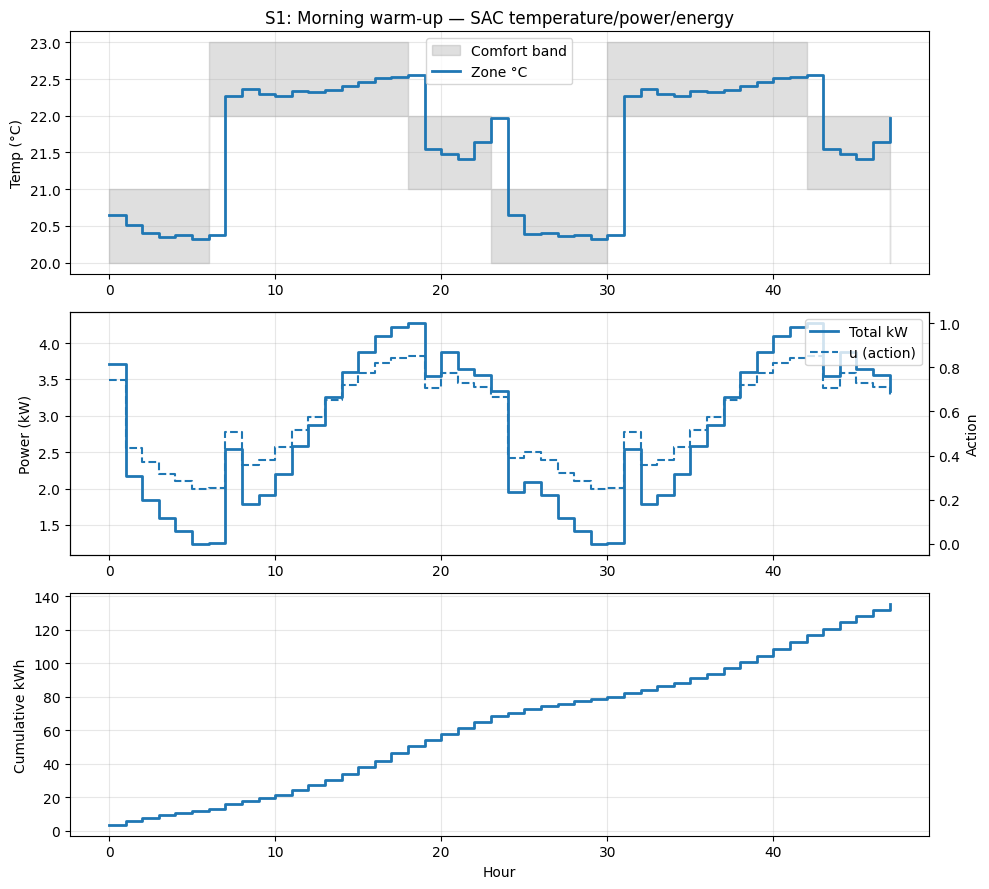

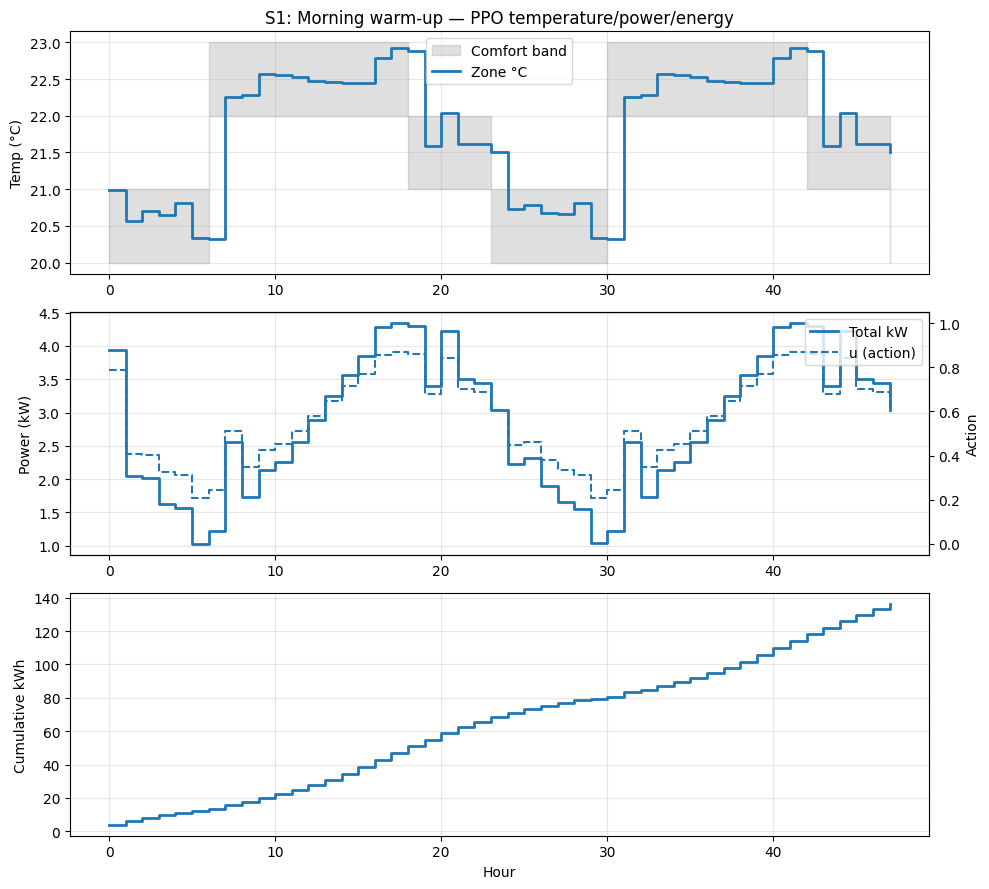

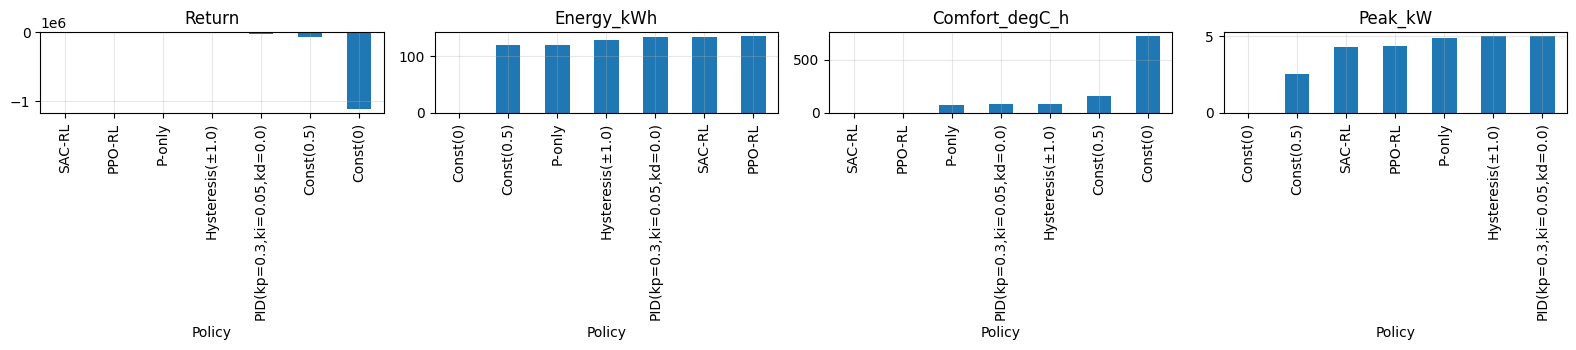

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndi


===== S2: DR window (cap+price) =====


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conver

Per-episode results:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Policy,Return,Energy_kWh,Comfort_degC_h,Comfort_penalty,Smooth_SumAbsDu,Peak_kW,Cost_USD
0,SAC-RL,-1.462359e+04,128.675001,33.880104,726.014851,6.962527,4.999781,14.867500
1,SAC-RL,-1.462359e+04,128.675001,33.880104,726.014851,6.962527,4.999781,14.867500
2,SAC-RL,-1.462359e+04,128.675001,33.880104,726.014851,6.962527,4.999781,14.867500
3,SAC-RL,-1.462359e+04,128.675001,33.880104,726.014851,6.962527,4.999781,14.867500
4,SAC-RL,-1.462359e+04,128.675001,33.880104,726.014851,6.962527,4.999781,14.867500
5,PPO-RL,-1.374870e+04,129.362863,32.681461,682.241820,7.459848,5.000000,14.936286
6,PPO-RL,-1.374870e+04,129.362863,32.681461,682.241820,7.459848,5.000000,14.936286
7,PPO-RL,-1.374870e+04,129.362863,32.681461,682.241820,7.459848,5.000000,14.936286
8,PPO-RL,-1.374870e+04,129.362863,32.681461,682.241820,7.459848,5.000000,14.936286
9,PPO-RL,-1.374870e+04,129.362863,32.681461,682.241820,7.459848,5.000000,14.936286



Summary (mean ± std):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Policy,Return_mean,Return_std,Energy_kWh_mean,Energy_kWh_std,Comfort_degC_h_mean,Comfort_degC_h_std,Comfort_penalty_mean,Comfort_penalty_std,Smooth_SumAbsDu_mean,Smooth_SumAbsDu_std,Peak_kW_mean,Peak_kW_std,Cost_USD_mean,Cost_USD_std
0,Const(0),-1.108019e+06,0.000000,0.000000,0.000000,724.052061,0.000000,55400.963976,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
1,Const(0.5),-1.036304e+05,0.000000,114.000000,0.000000,191.647058,0.000000,5176.956568,0.000000,1.700000,0.000000,2.500000,0.0,13.400000,0.000000
2,Hysteresis(±1.0),-4.808499e+04,0.000000,124.000000,0.000000,123.078751,0.000000,2399.209442,0.000000,32.000000,0.000000,5.000000,0.0,14.400000,0.000000
3,P-only,-3.701417e+04,0.000000,114.966322,0.000000,104.409927,0.000000,1846.075058,0.000000,13.928187,0.000000,5.000000,0.0,13.496632,0.000000
4,"PID(kp=0.3,ki=0.05,kd=0.0)",-4.163637e+04,1425.304235,128.697655,0.676063,110.349130,4.595051,2076.583219,71.234305,34.908762,1.545655,5.000000,0.0,14.869766,0.067606
5,PPO-RL,-1.374870e+04,0.000000,129.362863,0.000000,32.681461,0.000000,682.241820,0.000000,7.459848,0.000000,5.000000,0.0,14.936286,0.000000
6,SAC-RL,-1.462359e+04,0.000000,128.675001,0.000000,33.880104,0.000000,726.014851,0.000000,6.962527,0.000000,4.999781,0.0,14.867500,0.000000


/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))


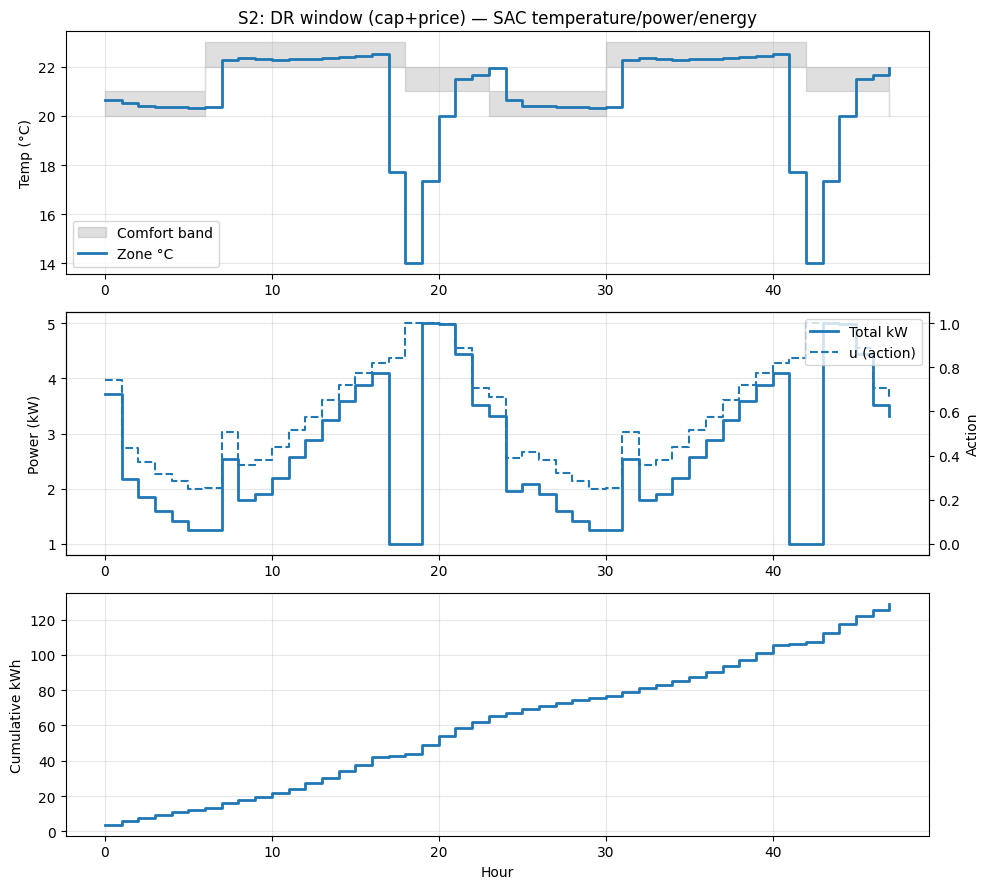

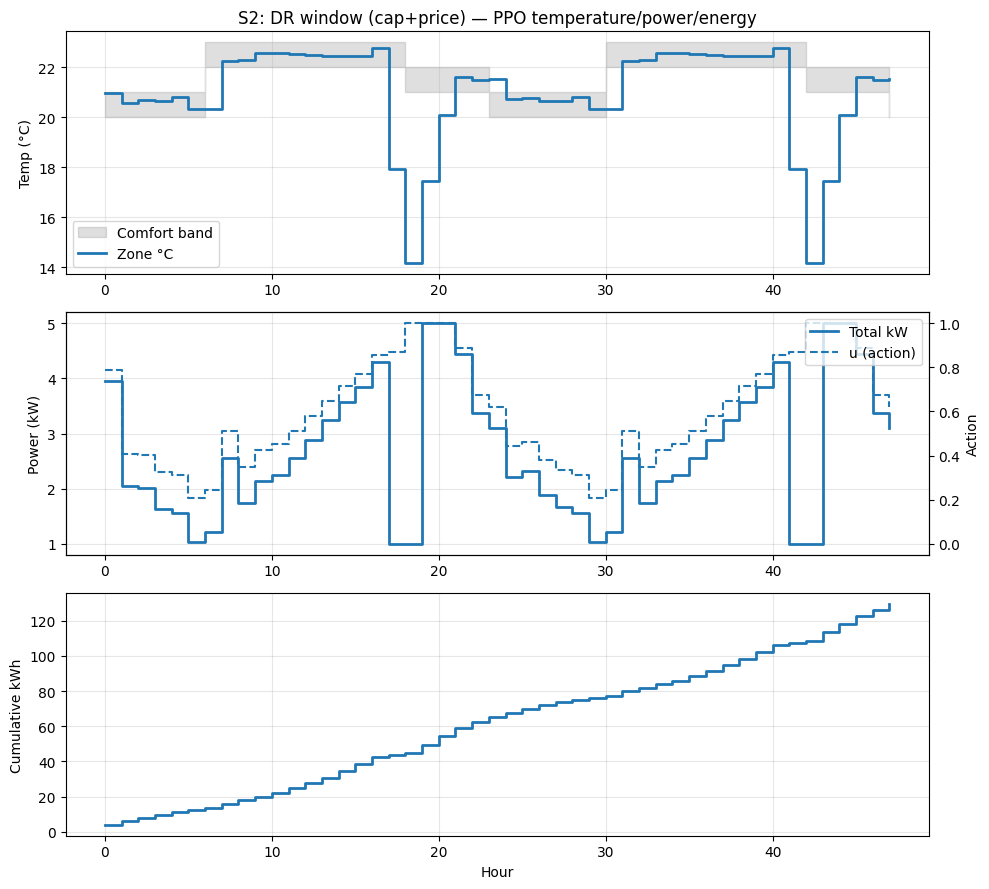

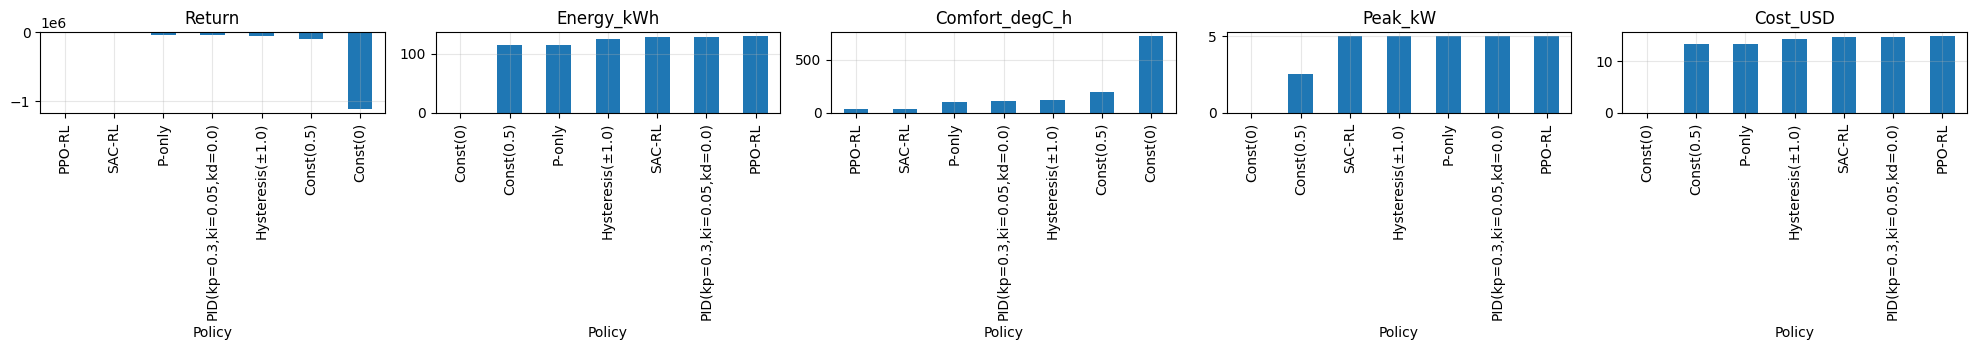

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndi


===== S3: 60% capacity derate =====
Per-episode results:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conver

,Policy,Return,Energy_kWh,Comfort_degC_h,Comfort_penalty,Smooth_SumAbsDu,Peak_kW,Cost_USD
0,SAC-RL,-1.527066e+04,119.977194,66.216384,758.727257,2.610031,3.0,0.0
1,SAC-RL,-1.527066e+04,119.977194,66.216384,758.727257,2.610031,3.0,0.0
2,SAC-RL,-1.527066e+04,119.977194,66.216384,758.727257,2.610031,3.0,0.0
3,SAC-RL,-1.527066e+04,119.977194,66.216384,758.727257,2.610031,3.0,0.0
4,SAC-RL,-1.527066e+04,119.977194,66.216384,758.727257,2.610031,3.0,0.0
5,PPO-RL,-1.503218e+04,120.759291,65.477289,746.771749,2.824863,3.0,0.0
6,PPO-RL,-1.503218e+04,120.759291,65.477289,746.771749,2.824863,3.0,0.0
7,PPO-RL,-1.503218e+04,120.759291,65.477289,746.771749,2.824863,3.0,0.0
8,PPO-RL,-1.503218e+04,120.759291,65.477289,746.771749,2.824863,3.0,0.0
9,PPO-RL,-1.503218e+04,120.759291,65.477289,746.771749,2.824863,3.0,0.0



Summary (mean ± std):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Policy,Return_mean,Return_std,Energy_kWh_mean,Energy_kWh_std,Comfort_degC_h_mean,Comfort_degC_h_std,Comfort_penalty_mean,Comfort_penalty_std,Smooth_SumAbsDu_mean,Smooth_SumAbsDu_std,Peak_kW_mean,Peak_kW_std,Cost_USD_mean,Cost_USD_std
0,Const(0),-1.108019e+06,0.000000,0.000000,0.000000,724.052061,0.000000,55400.963976,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,Const(0.5),-6.074737e+04,0.000000,120.000000,0.000000,160.420727,0.000000,3032.567050,0.000000,0.500000,0.000000,2.5,0.0,0.0,0.0
2,Hysteresis(±1.0),-1.754719e+04,0.000000,120.000005,0.000000,89.137407,0.000000,872.542978,0.000000,6.600000,0.000000,3.0,0.0,0.0,0.0
3,P-only,-2.159693e+04,0.000000,114.023106,0.000000,103.569059,0.000000,1075.270319,0.000000,6.202534,0.000000,3.0,0.0,0.0,0.0
4,"PID(kp=0.3,ki=0.05,kd=0.0)",-1.781621e+04,144.234732,119.764459,0.526697,92.151121,1.628074,885.994899,7.189463,9.984262,0.482407,3.0,0.0,0.0,0.0
5,PPO-RL,-1.503218e+04,0.000000,120.759291,0.000000,65.477289,0.000000,746.771749,0.000000,2.824863,0.000000,3.0,0.0,0.0,0.0
6,SAC-RL,-1.527066e+04,0.000000,119.977194,0.000000,66.216384,0.000000,758.727257,0.000000,2.610031,0.000000,3.0,0.0,0.0,0.0


/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))


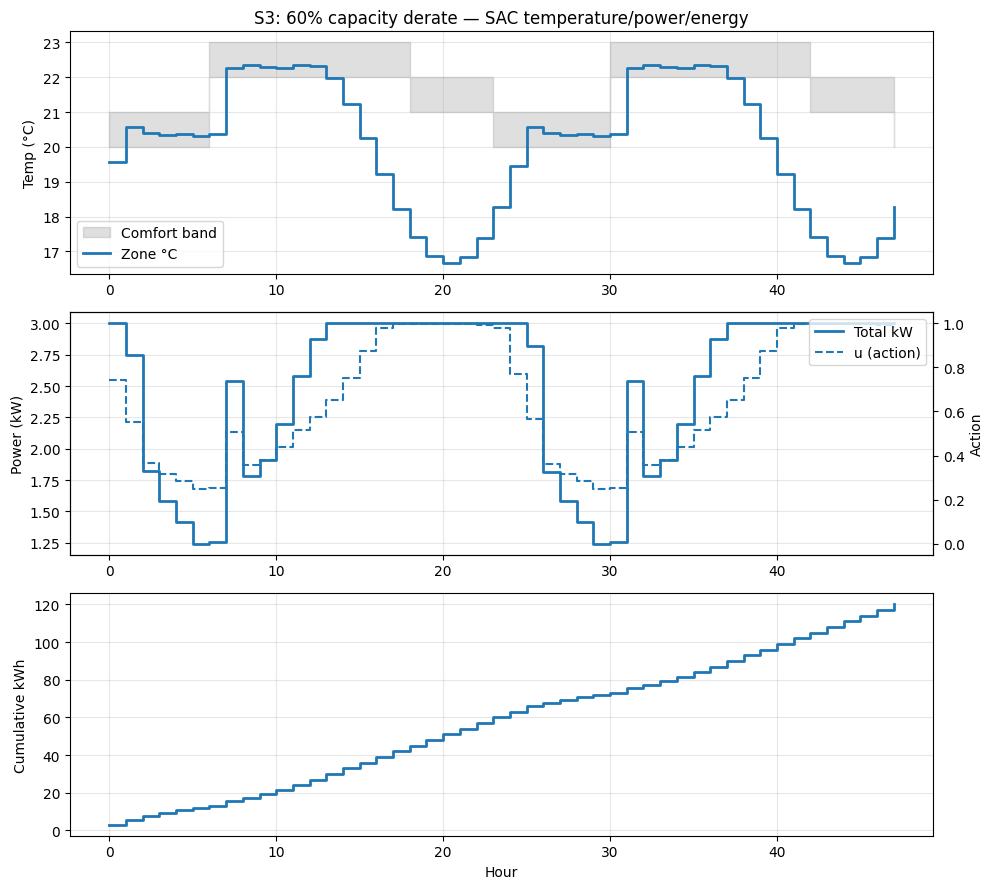

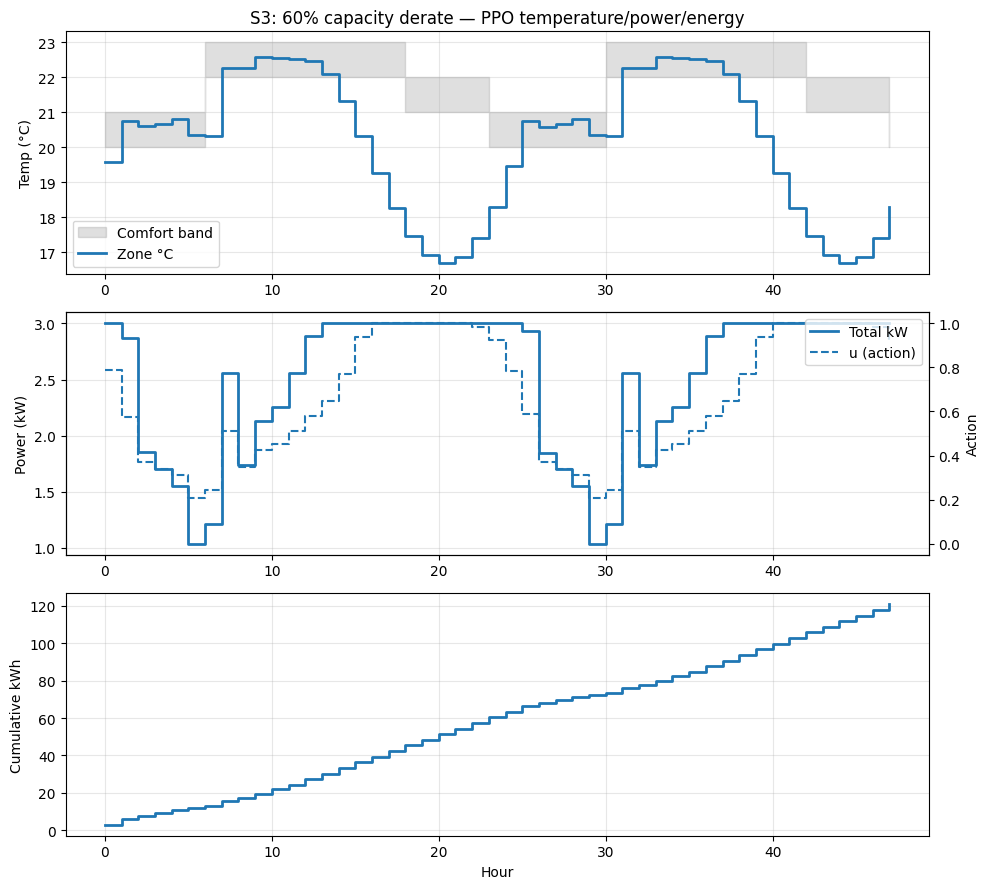

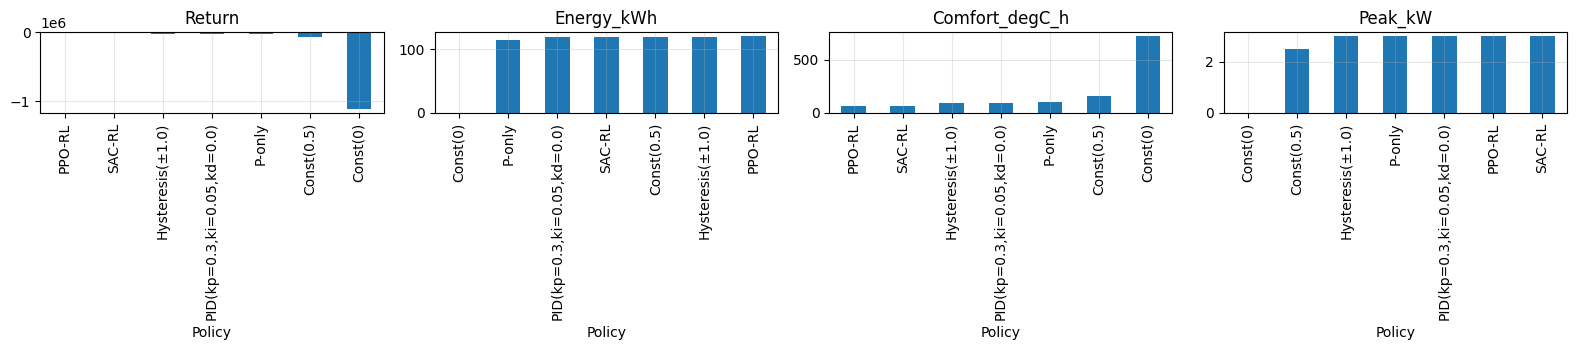

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndi


===== S4: Noisy sensor + lag =====


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndi

Per-episode results:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))
/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndi

,Policy,Return,Energy_kWh,Comfort_degC_h,Comfort_penalty,Smooth_SumAbsDu,Peak_kW,Cost_USD
0,SAC-RL,-1.639504e+03,154.808662,29.476999,75.776990,2.345483,4.867001,0.0
1,SAC-RL,-1.660811e+03,154.766284,29.519322,76.844103,2.310338,4.873002,0.0
2,SAC-RL,-1.694826e+03,154.996025,30.252262,78.535583,2.343935,4.869317,0.0
3,SAC-RL,-1.619067e+03,155.370788,28.815556,74.732595,2.361898,4.863323,0.0
4,SAC-RL,-1.647660e+03,154.559719,28.289013,76.194785,2.320616,4.867566,0.0
5,PPO-RL,-1.306367e+03,157.236772,23.221426,59.022678,2.470376,4.933309,0.0
6,PPO-RL,-1.474049e+03,156.607278,25.719506,67.431998,2.457317,4.941913,0.0
7,PPO-RL,-1.448960e+03,156.512697,25.370724,66.181249,2.497647,4.937742,0.0
8,PPO-RL,-1.505760e+03,156.744511,25.116679,69.012165,2.419780,4.937920,0.0
9,PPO-RL,-1.544156e+03,156.444190,27.343720,70.943956,2.436430,4.938172,0.0



Summary (mean ± std):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Policy,Return_mean,Return_std,Energy_kWh_mean,Energy_kWh_std,Comfort_degC_h_mean,Comfort_degC_h_std,Comfort_penalty_mean,Comfort_penalty_std,Smooth_SumAbsDu_mean,Smooth_SumAbsDu_std,Peak_kW_mean,Peak_kW_std,Cost_USD_mean,Cost_USD_std
0,Const(0),-1.569182e+06,0.000000,0.000000,0.000000,850.070122,0.000000,78459.075486,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,Const(0.5),-1.540081e+05,0.000000,114.166667,0.000000,232.350168,0.000000,7695.836046,0.000000,0.500000,0.000000,2.500000,0.000000,0.0,0.0
2,Hysteresis(±0.5),-6.246908e+03,2741.471680,153.423222,0.014337,53.915214,8.616327,306.192978,137.073154,6.203419,0.124792,4.961476,0.006144,0.0,0.0
3,P-only,-1.254855e+04,286.365170,139.062416,0.220940,96.884661,1.923167,621.857949,14.320996,2.875486,0.165694,4.626151,0.058598,0.0,0.0
4,"PID(kp=0.2,ki=0.02,kd=0.0)",-5.290856e+03,3406.187339,157.869342,2.939644,39.189150,13.187564,258.213871,170.247766,5.670806,1.154849,4.965638,0.007852,0.0,0.0
5,PPO-RL,-1.455858e+03,90.847368,156.709089,0.315757,25.354411,1.474538,66.518409,4.553531,2.456310,0.030155,4.937811,0.003051,0.0,0.0
6,SAC-RL,-1.652373e+03,28.153886,154.900296,0.305318,29.270631,0.748114,76.416811,1.411296,2.336454,0.020723,4.868042,0.003529,0.0,0.0


/tmp/ipython-input-992436153.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(np.clip(action, 0.0, 1.0))


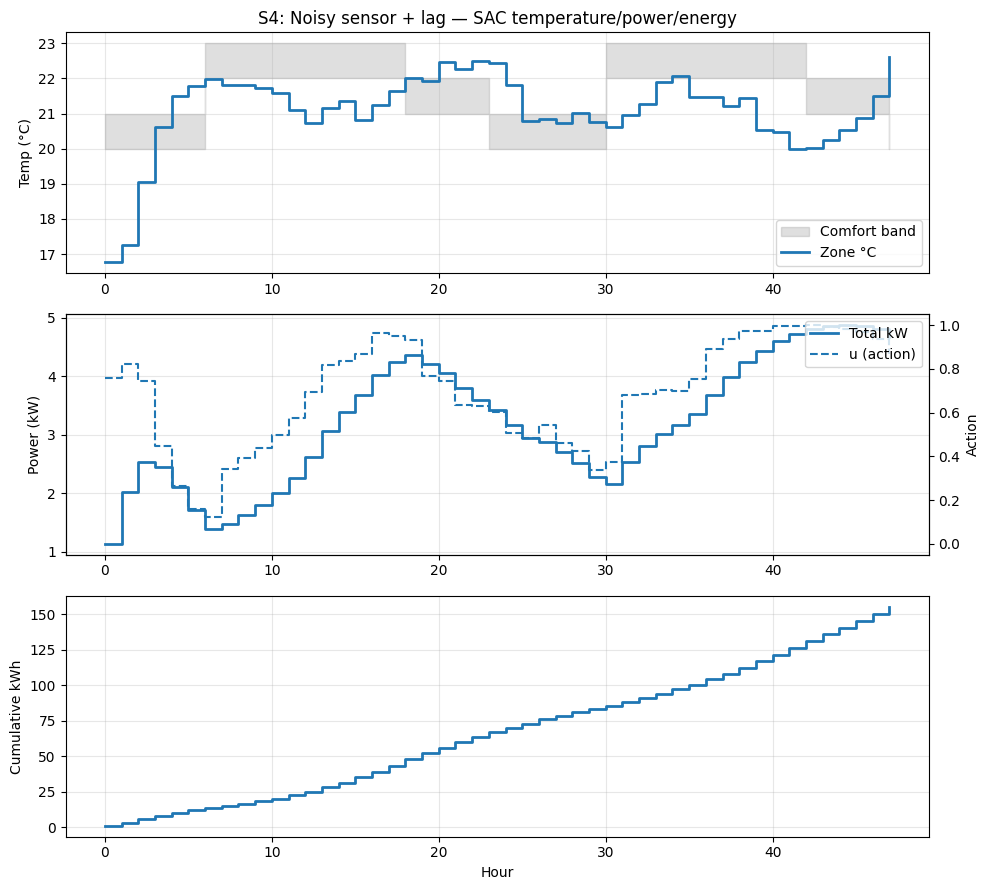

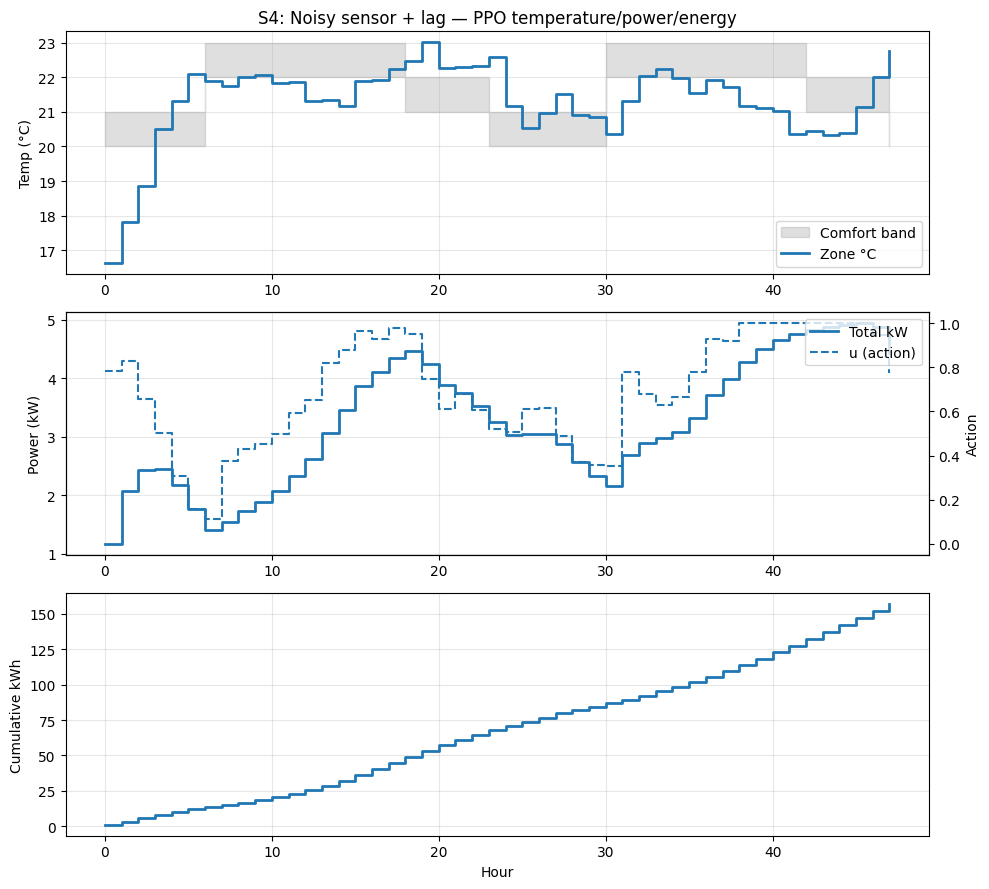

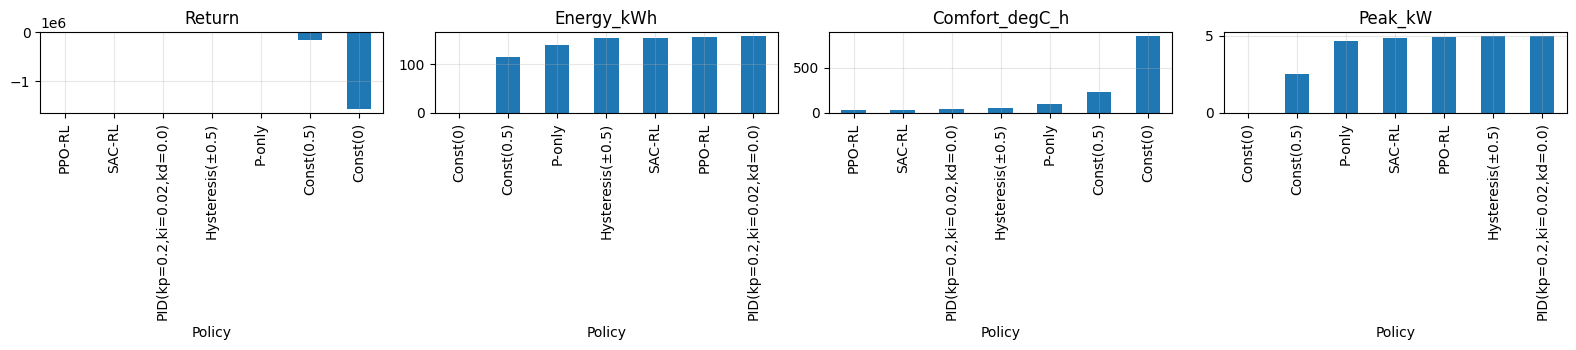

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Load models (if running in a fresh session)
# ppo = PPO.load("ppo_rcenv", env=venv_ppo)
# sac = SAC.load("sac_rcenv", env=venv_sac)

SCENARIOS = [
    ("S1: Morning warm-up",        make_env_S1, False),
    ("S2: DR window (cap+price)",  make_env_S2, True),
    ("S3: 60% capacity derate",    make_env_S3, False),
    ("S4: Noisy sensor + lag",     make_env_S4, False),
]

EP_BENCH = 5
all_results = {}

for scen_name, make_env_fn, show_cost in SCENARIOS:
    print(f"\n===== {scen_name} =====")

    # small grid to pick decent baselines
    comfort_cap = 60.0
    best_hys_fn, best_hys_row = None, None
    for d in [0.3, 0.5, 0.8, 1.0]:
        df = eval_policy(make_env_fn, 3, f"Hysteresis(±{d})", baseline_fn=make_hysteresis(d))
        row = df.mean(numeric_only=True)
        if row["Comfort_degC_h"] <= comfort_cap and (best_hys_row is None or row["Energy_kWh"] < best_hys_row["Energy_kWh"]):
            best_hys_fn, best_hys_row = make_hysteresis(d), row
    best_hys_fn = best_hys_fn or make_hysteresis(1.0)

    best_pid_fn, best_pid_row = None, None
    for kp in [0.2, 0.3, 0.4]:
        for ki in [0.02, 0.05]:
            df = eval_policy(make_env_fn, 3, f"PID({kp},{ki})", baseline_fn=make_PID(kp,ki,0.0))
            row = df.mean(numeric_only=True)
            if row["Comfort_degC_h"] <= comfort_cap and (best_pid_row is None or row["Energy_kWh"] < best_pid_row["Energy_kWh"]):
                best_pid_fn, best_pid_row = make_PID(kp,ki,0.0), row
    best_pid_fn = best_pid_fn or make_PID(0.3,0.05,0.0)

    dfs = [
        eval_policy(make_env_fn, EP_BENCH, "SAC-RL", model=sac, vecnorm=venv_sac),
        eval_policy(make_env_fn, EP_BENCH, "PPO-RL", model=ppo, vecnorm=venv_ppo),
        eval_policy(make_env_fn, EP_BENCH, getattr(best_hys_fn,"__name__","Hysteresis"), baseline_fn=best_hys_fn),
        eval_policy(make_env_fn, EP_BENCH, getattr(best_pid_fn,"__name__","PID"), baseline_fn=best_pid_fn),
        eval_policy(make_env_fn, EP_BENCH, "P-only", baseline_fn=make_P(0.25)),
        eval_policy(make_env_fn, EP_BENCH, "Const(0)", baseline_fn=make_const(0.0)),
        eval_policy(make_env_fn, EP_BENCH, "Const(0.5)", baseline_fn=make_const(0.5)),
    ]
    results = pd.concat(dfs, ignore_index=True)
    all_results[scen_name] = results

    print("Per-episode results:"); display(results)
    print("\nSummary (mean ± std):"); display(summarize(results))

    # one nice trace for both RLs
    env = make_env_fn()
    m1, tr1 = run_episode_norm(env, sac, venv_sac)
    plot_one(tr1, title=f"{scen_name} — SAC temperature/power/energy")

    env = make_env_fn()
    m2, tr2 = run_episode_norm(env, ppo, venv_ppo)
    plot_one(tr2, title=f"{scen_name} — PPO temperature/power/energy")

    # quick bars
    metrics_to_plot = ["Return","Energy_kWh","Comfort_degC_h","Peak_kW"]
    if show_cost: metrics_to_plot.append("Cost_USD")
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4*len(metrics_to_plot), 3.6))
    for ax, m in zip(np.atleast_1d(axes), metrics_to_plot):
        s = results.groupby("Policy")[m].mean().sort_values(ascending=(m!="Return"))
        s.plot(kind="bar", ax=ax); ax.set_title(m); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
